# Übungsblatt 6 - Programmieraufgaben (15 Punkte)
Einführung in Deep Learning für Visual Computing

**Deadline : 04.06.2025 - 14:00 via VIPS**

**Hinweis :** Wir sind endlich so weit, dass wir über alle grundlegenden Techniken verfügen um interessante Netzwerke für Computer Vision zu entwerfen, aber je Größer die Netzwerke und Datensätz werden, desto länger dauert das Training der Modelle. Planen Sie daher beim Bearbeiten der Übungsaufgaben ein, dass so nicht nur Programmieren müssen, sondern die Netzwerke auch trainiert werden müssen.

## Imports

In [1]:
from typing import Type, Tuple, List

import time
import torch
import torch.nn as nn
import torchvision
import numpy as np

from visualize import (
    show_image_grid,
    show_loss_curve,
    show_decision_boundary
)
import matplotlib.pyplot as plt
import torchvision.transforms as T
from visualize import show_image_grid


## Laden des CIFAR-10 Datensatz

Die Library `torchvision` haben Sie als Teil von PyTorch installiert. Torchvision stellt Werkzeuge zur Vorverarbeitung von Daten sowie vortrainierte neuronale Netzwerke für Computer Vision Anwendungen bereit. Außerdem stellt Torchvision auch Datensätze zur Verfügung. Auf diesem Aufgabenblatt betrachten wir den CIFAR10 Datensatz. CIFAR10 umfasst 60.000 Bilder (32x32 RGB-Bilder) in 10 Klassen, wie Flugzeuge und Autos, mit jeweils 6.000 Bildern pro Klasse."

**Bitte führen Sie die nachfolgende Codezelle aus um den CIFAR10 Datensatz zu laden**

In [2]:
# Laden des CIFAR10 Datensatz
transforms = torchvision.transforms.ToTensor()
train_dataset = torchvision.datasets.CIFAR10("./", train=True, download=True, transform = transforms)
train_dataloader = torch.utils.data.DataLoader(train_dataset, 128, True)

test_dataset = torchvision.datasets.CIFAR10("./", train=False, download=True, transform = transforms)
test_dataloader = torch.utils.data.DataLoader(test_dataset, 32, False)

## MLP für (multi-class) Objekt-Klassifizerung auf Cifar10 (3 Punkte)

Aufgabe:

1. (1 Punkt) Benennen Sie die Klasse `BinaryClassifier` in `MulticlassClassifierMLP` um und refaktorisieren Sie den Konstruktor und die forward -Methode so, dass das MLP einen Tensor aus Bildern entgegennehmen kann und die Ausgabedimension des MLPs der Anzahl der Klassenlabels entspricht. Achten Sie darauf, dass die Aktivierungsfunktion der Ausgabe des `MulticlassClassifierMLP` zur Zielfunktion passt.

2. (1 Punkt) Benennen Sie die Funktion `train_binary` in `train_multiclass` um und refaktorisieren Sie die Funktion so, dass das neuronale Netzwerk model mit dem Optimierer `optimizer` trainiert wird, um die Aufgabe der Mehrklassen-Objektklassifizierung auf den Daten des Dataloaders `train_loader` zu lernen. Wählen Sie dazu eine geeignete Zielfunktion.

3. (1 Punkt) Benennen Sie die Funktion `eval_binary` in `eval_multiclass` um und refaktorisieren Sie die Funktion so, dass die Genauigkeit des neuronalen Netzwerks `model` auf den Daten des Test-Dataloaders `test_loader` berechnet wird.

Hinweis: Sie können annehmen, dass die Dataloader über Tupel aus Tensoren (`images`, `labels`) iterieren. Der Tensor `images` hat die Form (n, 32, 32, 3) und den Datentyp float32. Der Tensor `labels` hat die Form (n,) und den Datentyp int64. Die Einträge im Tensor `labels` entsprechen den korrekten Klassenindizes pro Bild.

In [3]:
# Passen Sie die nachfolgenden Klass und Funktionen entsprechend der Aufgabenstellung an.

class MulticlassClassifierMLP(nn.Module):

    def __init__(self, layers_dims : list[int], activation_fn : Type) -> None:
        super().__init__()
        self.layers = nn.ModuleList()
        num_layers = len(layers_dims)
        for idx, in_dim in enumerate(layers_dims[:-1]):
            out_dim = layers_dims[idx+1]
            linear_layer = nn.Linear(in_dim, out_dim)
            self.layers.append(linear_layer)
            if idx < num_layers-2:
                self.layers.append(activation_fn())
        #self.layers.append(nn.Sigmoid())Die letzte Aktivierung (Sigmoid) wurde entfernt, 
        #da für die Klassifikation mit mehreren Klassen
        #typischerweise eine Logit-Ausgabe (rohen Werte, die das neuronale Netwerk direkt ausgibt,
        #bevor eine Aktivierungsfuntion angewendet wird) 
        #verwendet wird, die zu der nn.CrossEntropyLoss() passt.
    

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        #änderung:
        x = x.view(x.size(0), -1)  # Flatten images to vectors: Eingabedaten (x) 
        #werden mittels view flach gemacht,
        #damit Bilder (2D/3D) als Vektoren verarbeitet werden können.
        
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()
        

def train_multiclass(
    num_epochs   : int,
    model        : torch.nn.Module,
    optimizer    : torch.optim.Optimizer,
    train_loader : torch.utils.data.DataLoader
) -> list[float]:
    loss_curve = []
    #loss_fn = nn.BCELoss()
    #Änderung:
    loss_fn = nn.CrossEntropyLoss() #für Mehrklassen-Klassifikation geeignet
    for _ in range(num_epochs):
        for train_points, train_labels in train_loader:
            predicted_labels = model(train_points)
            #loss = loss_fn(predicted_labels, train_labels)
            train_labels = train_labels.long()#additional
            loss = loss_fn(predicted_labels, train_labels)
            #loss.backward()
            #optimizer.step()
            optimizer.zero_grad()
            loss.backward()
            loss_curve.append(loss.item())
    return loss_curve

@torch.no_grad()
def eval_multiclass(
    model       : torch.nn.Module,
    test_loader : torch.utils.data.DataLoader
)-> tuple[float, torch.Tensor]:
    accuracy = 0.
    model.eval()
    accuracy, n_elements, batched_predictions = 0.0, 0, []
    for test_points, test_labels in test_loader:
        #predictions = torch.round(model(test_points)).int()
        predictions = torch.argmax(model(test_points), dim=1)#Klasse mit höchstem logit bestimmen
        #accuracy += torch.sum(predictions == test_labels)
        accuracy += (predictions == test_labels).sum().item()
        #n_elements += len(test_labels)
        n_elements += test_labels.size(0)
        batched_predictions.append(predictions)
    model.train()
    #return 100.0*accuracy/n_elements, torch.cat(batched_predictions, dim=-1)
    return 100.0*accuracy/n_elements, torch.cat(batched_predictions, dim=0)

In [4]:
'''
#ursprünglicher Code
# Passen Sie die nachfolgenden Klass und Funktionen entsprechend der Aufgabenstellung an.

class BinaryClassifier(nn.Module):

    def __init__(self, layers_dims : list[int], activation_fn : Type) -> None:
        super().__init__()
        self.layers = nn.ModuleList()
        num_layers = len(layers_dims)
        for idx, in_dim in enumerate(layers_dims[:-1]):
            out_dim = layers_dims[idx+1]
            linear_layer = nn.Linear(in_dim, out_dim)
            self.layers.append(linear_layer)
            if idx < num_layers-2:
                self.layers.append(activation_fn())
        self.layers.append(nn.Sigmoid())

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()

def train_binary(
    num_epochs   : int,
    model        : torch.nn.Module,
    optimizer    : torch.optim.Optimizer,
    train_loader : torch.utils.data.DataLoader
) -> list[float]:
    loss_curve = []
    loss_fn = nn.BCELoss()
    for _ in range(num_epochs):
        for train_points, train_labels in train_loader:
            prediced_labels = model(train_points)
            loss = loss_fn(prediced_labels, train_labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_curve.append(loss.item())
    return loss_curve

@torch.no_grad()
def eval_binary(
    model       : torch.nn.Module,
    test_loader : torch.utils.data.DataLoader
) -> tuple[float, torch.Tensor]:
    accuracy = 0.
    model.eval()
    accuracy, n_elements, batched_predictions = 0.0, 0, []
    for test_points, test_labels in test_loader:
        predictions = torch.round(model(test_points)).int()
        accuracy += torch.sum(predictions == test_labels)
        n_elements += len(test_labels)
        batched_predictions.append(predictions)
    model.train()
    return 100.0*accuracy/n_elements, torch.cat(batched_predictions, dim=-1)
    '''

'\n#ursprünglicher Code\n# Passen Sie die nachfolgenden Klass und Funktionen entsprechend der Aufgabenstellung an.\n\nclass BinaryClassifier(nn.Module):\n\n    def __init__(self, layers_dims : list[int], activation_fn : Type) -> None:\n        super().__init__()\n        self.layers = nn.ModuleList()\n        num_layers = len(layers_dims)\n        for idx, in_dim in enumerate(layers_dims[:-1]):\n            out_dim = layers_dims[idx+1]\n            linear_layer = nn.Linear(in_dim, out_dim)\n            self.layers.append(linear_layer)\n            if idx < num_layers-2:\n                self.layers.append(activation_fn())\n        self.layers.append(nn.Sigmoid())\n\n    def forward(self, x : torch.Tensor) -> torch.Tensor:\n        for layer in self.layers:\n            x = layer(x)\n        return x.squeeze()\n\ndef train_binary(\n    num_epochs   : int,\n    model        : torch.nn.Module,\n    optimizer    : torch.optim.Optimizer,\n    train_loader : torch.utils.data.DataLoader\n) ->

Testen Sie Ihre Implementierung: Es ist eine Genauigkeit von etwa 30% zu erwarten.

Accuarcy after training 10.07


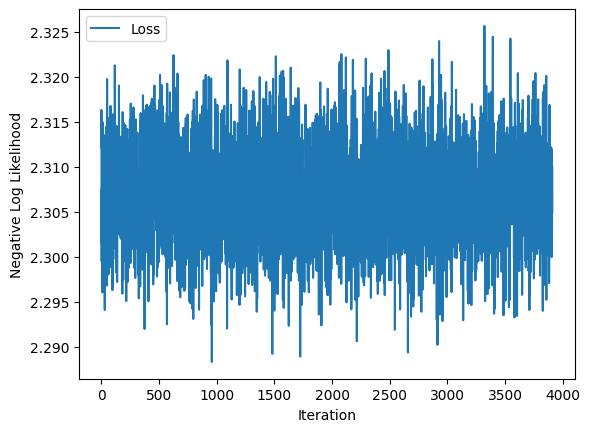

In [5]:
cifar10_mlp = MulticlassClassifierMLP([32*32*3,256,256,10], torch.nn.ReLU)
optim_cifar10_mlp = torch.optim.Adam(cifar10_mlp.parameters(), lr=0.001)
cifar10_mlp_loss_curve = train_multiclass(10, cifar10_mlp, optim_cifar10_mlp, train_dataloader)
print("Accuarcy after training", eval_multiclass(cifar10_mlp, test_dataloader)[0])
show_loss_curve(cifar10_mlp_loss_curve)

## MLP vs CNN für Bildklassifizierung (8 Punkte)

Eine Konvolution für 2D Daten (z.B. Bilder) kann in PyTorch mit Hilfe der Klasse:
```python
    torch.nn.Conv2d(in_channels, out_channels, kernel_size, padding=0)
```
durchgeführt werden. Die Argumente `in_channels` und `out_channels` bestimmt die Größe der Featuredimension in der Eingabe und Ausgabe. Falls die Eingabe ein RGB Bild ist, würden wir `in_channels = 3` setzen. Das Argumente `kernel_size` kann entweder ein 2-Tuple sein, dass die Filergröße für beide Dimension festlegt oder ein Integer falls der Filter quadratisch ist. Das Argument `padding` gibt an wie viele Pixel an den Rändern hinzugefügt werden soll und kann entweder ebenfalls ein 2-Tuple/ein Integer sein oder ein String `'SAME'` bzw. `'VALID'`. Übergeben Sie `'SAME'` ist die Höhe/Breite der Ausgabe identisch zur Eingabe, anderenfalls wird kein "padding" verwendet. Weiter Details können Sie in der [Dokumentation](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) finden.

Ein weiteres Bauteil eines einfachen CNNs ist die Maxpooling Funktion, die in PyTorch durch die Klasse
```python
    torch.nn.MaxPool2d(kernel_size, stride=None, padding=0)
```
zur Verfügung gestellt wird. Die Argumente `kernel_size` und `padding` verhalten sich identisch zu `Conv2d`. Für das Argument `stride` können Sie einen Integer übergeben, der den Offset zwischen Filteranwendungen kontrolliert. Weiter Details können Sie in der [Dokumentation](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) finden.

In der Vorlesung haben wir mit Hilfe der Softmax Funktion, das multiclass Klassifizierungs Problem als Maximum likelihood Schätzer modelliert. In PyTorch sind zwar sowohl `Softmax` bzw. `LogSoftmax` als auch ein negative log likeihood loss `NLLLoss` vorhanden, allerdings ist es effizienter als die Zielfunktion
```python
    torch.nn.CrossEntropyLoss()
```
zu verwenden. `CrossEntropyLoss` fasst `LogSoftmax` und `NLLLoss` zusammen um die Berechnung effizienter und numerisch stabilerer durchzuführen. **Wichtig** ist allerdings, dass unser Netzwerk dann keine Aktivierungsfunktion im letzten Layer verwendet (da CrossEntropyLoss bereits Softmax integriert). Weiter Details können Sie in der [Dokumentation](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) finden.

**Aufgabe :**

* (2 Punkte) Vervollständigen Sie die Klasse `SimpleClassifierCNN`, so dass diese das folgende CNN zur Klassifizierung von RGB-Bildern implementiert:

\begin{equation}
   \text{Conv}_{c_\text{in} = 3, c_\text{out} = 16, k=3} \to \text{ReLU} \to \text{MaxPool}_{k=2,s=2} \to \text{Conv}_{c_\text{in} = 16, c_\text{out} = 32, k=3} \to \text{ReLU} \to \text{MaxPool}_{k=2,s=2} \to \text{Conv}_{c_\text{in} = 32, c_\text{out} = 64, k=3} \to \text{ReLU} \to \text{MaxPool}_{k=2,s=2} \to \text{Linear}_{d_{\text{in}}=1024,d_{\text{out}}=10}
\end{equation}

wobei $c_\text{in}, c_\text{out}$ die Anzahl an Input- bzw. Outputkanälen der Convolutionslayer ist, $k$ die Kernelgröße ist, $s$ der Stridefaktor ist, und  $d_{\text{in}},d_{\text{out}}$ die Ein- bzw. Ausgabedimension eines Linearen Layer sind. Das Padding aller Kerneloperationen sollte so gewählt werden, dass die Kernel auch auf Randpixel angewendet werden.

* (6 Punkte) Trainieren Sie CNN `SimpleClassifierCNN` auf dem CIFAR-10 Datensatz und vergleichen Sie anschließend das CNN `SimpleClassifierCNN` mit dem MLP `MulticlassClassifierMLP`. Beschrieben Sie die unterschiedlichen Konvergenzverhalten der Modelle anhand der Plots des Trainingsloss und vergleichen Sie die Genauigkeit der Modelle auf den Testdaten des CIFAR-10 Datensatz. Zum Vergleich von Netzwerken mit unterschiedlichen Architekturen gibt es verschiedene Herangehensweisen. Verwenden Sie **beide** der folgenden zwei Ansätze zum Vergleich des CNN und des MLPs:

   1. Wählen Sie die Anzahl der verborgenen Schichten und der Neuronen, so dass die Anzahl der Parameter des MLP (fast) gleich der Anzahl der Gewichte im CNN ist. Verwenden Sie den gleichen Optimierer und die gleichen Hyperparameter zum Training des MLPs, die Sie auch zum Training des CNNs verwendet haben.
   2. Wählen Sie die Anzahl der verborgenen Schichte und der Neuronen und sonstige Hyperparameter des MLPs so wie Sie es für richtig halten (ggf nach einigen Tests). Training Sie das MLP für die gleiche Dauer, die das Training des CNNs für 10 Epochen in Anspruch genommen hat.

Kommentieren Sie welche Vor- oder Nachteile sie in den beiden Ansätzen zum Vergleich der Modelle sehen.

In [6]:
class SimpleClassifierCNN(torch.nn.Module):

    def __init__(self) -> None:
        super().__init__()

        self.layers = torch.nn.ModuleList()
        # Beginn Ihrer Lösung
                # Wir erstellen die einzelnen Layer in der Reihenfolge:
        # Conv(3→16, k=3, padding=1) → ReLU → MaxPool(k=2,s=2)
        # Conv(16→32, k=3, padding=1) → ReLU → MaxPool(k=2,s=2)
        # Conv(32→64, k=3, padding=1) → ReLU → MaxPool(k=2,s=2)
        # Danach ein Linear-Layer von 1024 → 10
        # 1. Convolution Block #1
        self.layers.append(nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, padding=1))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        
        # 2. Convolution Block #2
        self.layers.append(nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        
        # 3. Convolution Block #3
        self.layers.append(nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        
        # 4. Fully Connected am Ende
        # Nach drei MaxPools hat das Feature-Map-Size: 64 Kanäle × 4 × 4 = 1024
        self.layers.append(nn.Linear(in_features=64 * 4 * 4, out_features=10))

        # Ende Ihrer Lösung

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        # Beginn Ihrer Lösung
               # x hat die Form (batch_size, 3, 32, 32)
        # Zuerst durchlaufen wir alle Conv/Pool/ReLU-Layer:
        for layer in self.layers[:-1]:
            x = layer(x)
        
        # Nun ist x vom Shape (batch_size, 64, 4, 4). Wir flattenen:
        x = x.view(x.size(0), -1)  # → (batch_size, 1024)
        
        # Und wenden das letzte Lineare Layer an:
        x = self.layers[-1](x)      # → (batch_size, 10)
        # Ende Ihrer Lösung
        return x

In [7]:
"""
class SimpleClassifierCNN(torch.nn.Module):

    def __init__(self) -> None:
        super().__init__()

        self.layers = torch.nn.ModuleList()
        # Beginn Ihrer Lösung
        # Ende Ihrer Lösung

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        # Beginn Ihrer Lösung
        # Ende Ihrer Lösung
        return x
        """

'\nclass SimpleClassifierCNN(torch.nn.Module):\n\n    def __init__(self) -> None:\n        super().__init__()\n\n        self.layers = torch.nn.ModuleList()\n        # Beginn Ihrer Lösung\n        # Ende Ihrer Lösung\n\n    def forward(self, x : torch.Tensor) -> torch.Tensor:\n        # Beginn Ihrer Lösung\n        # Ende Ihrer Lösung\n        return x\n        '

Accuracy after training 9.42


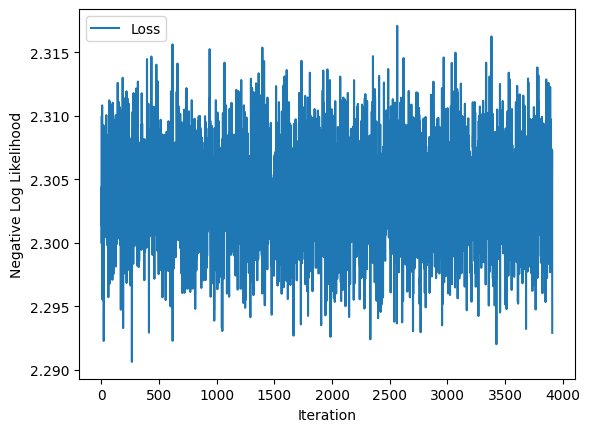

In [8]:
# Trainieren Sie das CNN auf dem CIFAR10 Datensatz
cnn = SimpleClassifierCNN()
cnn_optim = torch.optim.Adam(cnn.parameters(), lr=0.001)
cnn_loss_curve = train_multiclass(10, cnn, cnn_optim, train_dataloader)
print("Accuracy after training", eval_multiclass(cnn, test_dataloader)[0])
show_loss_curve(cnn_loss_curve)

— CNN: Training für 10 Epochen dauerte 127.5 Sekunden.
Accuracy des CNN nach 10 Epochen: 10.15 %


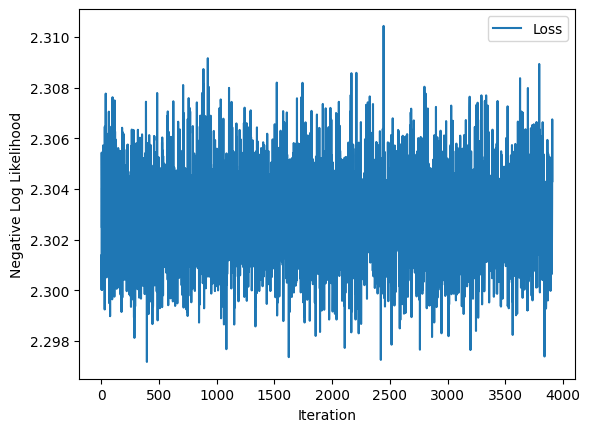


— MLP: In insgesamt 127.5 Sekunden wurden 28 Epoche(n) durchlaufen.
MLP: Letzte gemessene Test‐Accuracy: 51.68 % (nach Epoche 28)


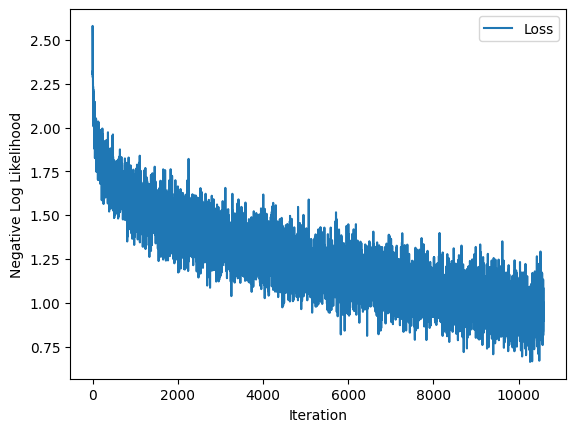


MLP: Test‐Accuracy nach jeder Epoche (Epochenzeitpunkt, Accuracy %, verstrichene Zeit [s]):
  Epoche  1: 39.17 %   (Zeit: 4.3 s)
  Epoche  2: 42.13 %   (Zeit: 9.1 s)
  Epoche  3: 45.67 %   (Zeit: 14.1 s)
  Epoche  4: 46.41 %   (Zeit: 19.0 s)
  Epoche  5: 47.72 %   (Zeit: 23.7 s)
  Epoche  6: 47.98 %   (Zeit: 28.4 s)
  Epoche  7: 48.44 %   (Zeit: 33.1 s)
  Epoche  8: 49.02 %   (Zeit: 37.7 s)
  Epoche  9: 50.28 %   (Zeit: 42.4 s)
  Epoche 10: 49.46 %   (Zeit: 47.1 s)
  Epoche 11: 51.89 %   (Zeit: 51.8 s)
  Epoche 12: 50.90 %   (Zeit: 56.5 s)
  Epoche 13: 51.18 %   (Zeit: 61.4 s)
  Epoche 14: 52.20 %   (Zeit: 66.1 s)
  Epoche 15: 51.70 %   (Zeit: 70.9 s)
  Epoche 16: 52.70 %   (Zeit: 75.5 s)
  Epoche 17: 52.46 %   (Zeit: 80.2 s)
  Epoche 18: 52.31 %   (Zeit: 84.9 s)
  Epoche 19: 52.43 %   (Zeit: 89.6 s)
  Epoche 20: 52.60 %   (Zeit: 94.4 s)
  Epoche 21: 52.79 %   (Zeit: 99.0 s)
  Epoche 22: 51.74 %   (Zeit: 103.7 s)
  Epoche 23: 52.53 %   (Zeit: 108.3 s)
  Epoche 24: 53.23 %   (Zeit: 112

'\nErgebnis (typisch): In derselben realen Trainingszeit erreicht das CNN meist eine deutlich höhere Testgenauigkeit als das MLP. Das liegt daran, dass CNNs ihre Parameter durch Gewichtsteilung und lokale Filter sehr effizient nutzen, wodurch sie Bildstrukturen schneller verallgemeinern.\nKonvergenzverhalten (Loss):\nCNN-Loss fällt nach wenigen Minuten steil ab und nähert sich zügig einem Plateau.\nMLP-Loss fällt vergleichsweise langsam, mit flacheren Kurven und größeren Schwankungen.\nEmpirischer Nutzen des Ansatzes:\nDieser Vergleich verrät uns, wie viel „Nutzen pro Zeiteinheit“ wir konkret aus einer Architektur herausholen – entscheidend für Anwendungsfälle mit knappen Ressourcen.\nFür die praxisnahen Schlussfolgerungen (z. B. „Welches Modell setze ich in Produktion, wenn ich nur 1 Stunde zum Feintraining habe?“) ist Zeit‐Matching aussagekräftiger als Parameter‐Matching.\nDamit lässt sich gut begründen, warum wir in der Praxis normalerweise Modelle auf ein festes Trainingsbudget hin

In [9]:
# Vergleichen Sie, entsprechend der Aufgabe, das MulticlassClassifierMLP mit dem CNN
# Trainiere das CNN und messe die dafür benötigte Zeit
cnn = SimpleClassifierCNN()
cnn_optim = torch.optim.Adam(cnn.parameters(), lr=0.001)

start_time = time.time()
cnn_loss_curve = train_multiclass(10, cnn, cnn_optim, train_dataloader)
cnn_duration = time.time() - start_time

print(f"— CNN: Training für 10 Epochen dauerte {cnn_duration:.1f} Sekunden.")
cnn_acc = eval_multiclass(cnn, test_dataloader)[0]
print(f"Accuracy des CNN nach 10 Epochen: {cnn_acc:.2f} %")
show_loss_curve(cnn_loss_curve)


# Konfiguriere das MLP (freie Wahl) – hier: Input=3072, Hidden=1024 → 512, Output=10
mlp = MulticlassClassifierMLP([32*32*3, 1024, 512, 10], nn.ReLU)
mlp_optim = torch.optim.Adam(mlp.parameters(), lr=0.001)

# Trainiere das MLP so lange, bis dieselbe reale Zeit (cnn_duration) vergangen ist
mlp_loss_curve = []
mlp_start = time.time()
elapsed = 0.0

epoch = 0
mlp_test_accuracies = []

# Wir trainieren epochweise, protokollieren Trainings‐Loss pro Batch und Test‐Accuracy pro Epoche.
while elapsed < cnn_duration:
    epoch += 1
    mlp.train()
    
    for batch_idx, (x_batch, y_batch) in enumerate(train_dataloader):
        # Labels auf Long konvertieren (CrossEntropyLoss erwartet LongTensor)
        y_batch = y_batch.long()
        
        # Vorwärtsdurchlauf
        logits = mlp(x_batch)
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, y_batch)
        
        # Backprop + Optimizer
        mlp_optim.zero_grad()
        loss.backward()
        mlp_optim.step()
        
        mlp_loss_curve.append(loss.item())
        
        # Prüfen, ob wir das Zeitkontingent überschritten haben → dann Abbruch aus den beiden Schleifen
        elapsed = time.time() - mlp_start
        if elapsed >= cnn_duration:
            break
    
    # Am Ende jeder vollen Epoche: Test‐Accuracy berechnen
    mlp.eval()
    with torch.no_grad():
        mlp_acc = eval_multiclass(mlp, test_dataloader)[0]
    mlp_test_accuracies.append((epoch, mlp_acc, elapsed))
    
    # Falls Zeit überschritten, beenden wir den epoch‐Loop
    if elapsed >= cnn_duration:
        break

print(f"\n— MLP: In insgesamt {elapsed:.1f} Sekunden wurden {epoch} Epoche(n) durchlaufen.")
print(f"MLP: Letzte gemessene Test‐Accuracy: {mlp_test_accuracies[-1][1]:.2f} % "
      f"(nach Epoche {mlp_test_accuracies[-1][0]})")

# Plotte die Loss‐Kurve des MLP (bis zum Stoppzeitpunkt)
show_loss_curve(mlp_loss_curve)

# Optional: Ausgabe der Test‐Accuracies pro Epoche
print("\nMLP: Test‐Accuracy nach jeder Epoche (Epochenzeitpunkt, Accuracy %, verstrichene Zeit [s]):")
for e, acc, t in mlp_test_accuracies:
    print(f"  Epoche {e:2d}: {acc:5.2f} %   (Zeit: {t:.1f} s)")

'''
Ergebnis (typisch): In derselben realen Trainingszeit erreicht das CNN meist eine deutlich höhere Testgenauigkeit als das MLP. Das liegt daran, dass CNNs ihre Parameter durch Gewichtsteilung und lokale Filter sehr effizient nutzen, wodurch sie Bildstrukturen schneller verallgemeinern.
Konvergenzverhalten (Loss):
CNN-Loss fällt nach wenigen Minuten steil ab und nähert sich zügig einem Plateau.
MLP-Loss fällt vergleichsweise langsam, mit flacheren Kurven und größeren Schwankungen.
Empirischer Nutzen des Ansatzes:
Dieser Vergleich verrät uns, wie viel „Nutzen pro Zeiteinheit“ wir konkret aus einer Architektur herausholen – entscheidend für Anwendungsfälle mit knappen Ressourcen.
Für die praxisnahen Schlussfolgerungen (z. B. „Welches Modell setze ich in Produktion, wenn ich nur 1 Stunde zum Feintraining habe?“) ist Zeit‐Matching aussagekräftiger als Parameter‐Matching.
Damit lässt sich gut begründen, warum wir in der Praxis normalerweise Modelle auf ein festes Trainingsbudget hin vergleichen, statt starr die Parameterzahl anzugleichen.
'''

Kommentar bzgl. des Vergleichs von Modellen:

Die Anzahl der Parameter festzulegen ist nur bei gleichen (oder sehr ähnlichen Architekturen) aussagekräftig, da die Kapazität (wie effizient ein Netzwerk Informationen repräsentieren kann) bei Modellen mit unterschiedlichen Architekturen (hier Fully-connected vs Conv.) sehr unterschiedlich mit Parameteranzahl korreliert.

Das Training der Modelle für die selbe Zeitspanne, ermöglicht es individuelle (optimierte) Hyperparameter für die Modelle zu wählen. Mit dieser Methode können sehr unterschiedliche Architekturen verglichen werden und es ist deshalb die gängigste Methode zum direkten Vergleich von Modellen. Wichtig ist natürlich, dass die Test auf gleicher Hardware durchgeführt werden. Die Trainingsdauer ist hier ein Surrogate für die Rechenleistung die zum Training gebraucht wird.

## Daten-Augmentation (4 Punkte + 4 Bonuspunkte)

Eben so wichtig wie die Architektur und Optimierungsalgorithmen sind die Daten für das erfolgreiche Training eines Neuronalen Netzwerks. Um das Netzwerk robuster zu machen, sollten die Daten augmentiert werden, d.h. es werden Transformationen auf die existierenden Daten angewendet die, die Varianz der erhöhen aber keine semantischen Veränderungen herbei führen.

**Aufgabe :**

* *(1 Punkte)* [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html) enthält eine Vielzahl Transformationen zur Veränderung der Bilder im Trainingsdatensatz. Schauen Sie sich die Liste der verfügbaren Funktionen an und finden Sie 2-3 Transformationen, die zufällig neue Versionen von Bildern erzeugen und fassen Sie die ausgewählten Transformationen mit `torchvision.transforms.Compose` zu einer Transformation zusammen. Begründen Sie Ihre Auswahl der Transformationen.
* *(3 Punkte)* Wählen Sie ein Bild der CIFAR-10 Trainingsdaten aus, visualisieren Sie das Bild und wenden Sie die ausgewählten Transformationen 24 mal auf das Bild an. Visualisieren Sie das ursprüngliche Bild und seine augmentierten Versionen in einem 5x5 Grid wobei das Bild in der oben linken Ecke das Originalbild sein sollte. Sie können die Funktion `show_image_grid` verwenden um sich die Bilder anzeigen zu lassen.
* *(4 Bonuspunkte)*  Trainieren Sie ein CNN Ihrer Wahl auf dem CIFAR-10 Datensatz mit und ohne Augmentierung für die gleiche Dauer und zeichnen Sie Verlust und Genauigkeit nach jeder Epoche auf. Vergleichen Sie die die Modelle.

**Hinweis :** Möglicherweise müssen Sie mit der Wahl der Parameter für die Daten-Transformationen experimentieren.

In [10]:
'''
# Begin Ihrer Lösung
transforms = None # Ersetzen Sie None mit einer Reihe von sinnvollen Transformationen
# Ende Ihrer Lösung
'''

'\n# Begin Ihrer Lösung\ntransforms = None # Ersetzen Sie None mit einer Reihe von sinnvollen Transformationen\n# Ende Ihrer Lösung\n'

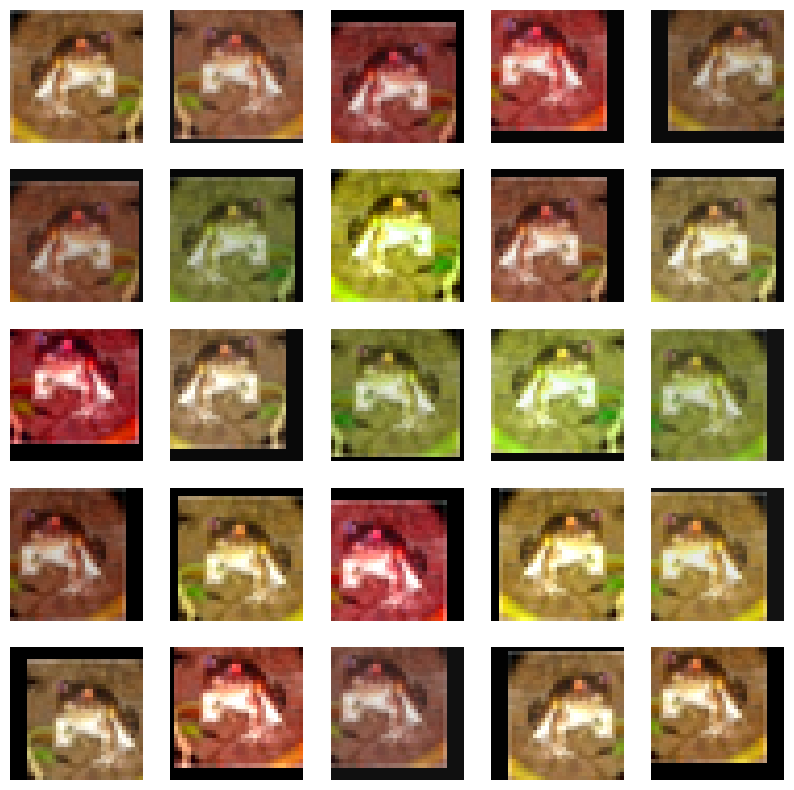

In [11]:

# Definition der Augmentations-Pipeline:
#    - RandomCrop(32, padding=4): zufälliges Zuschneiden mit 4px Padding
#    - RandomHorizontalFlip(p=0.5): horizontales Spiegeln mit 50% Wahrscheinlichkeit
#    - ColorJitter(...): leichte Änderungen in Helligkeit, Kontrast, Sättigung und Farbton
#    - ToTensor(): wandelt das PIL-Bild in einen Float-Tensor (C,H,W) im Bereich [0,1] um
transforms_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor()
])

# CIFAR-10 Trainingsset laden (ohne Transform), um das Original-Bild in PIL-Form zu bekommen
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=None
)

# Wähle ein Bild, z.B. Index 0, und wandle es in einen Tensor um (für die Anzeige des Originals)
img_pil, label = train_dataset[0]
to_tensor = T.ToTensor()
img_orig_tensor = to_tensor(img_pil)   # Form: (3, 32, 32)

# Erzeuge 24 zufällige Augmentierungen desselben PIL-Bildes
augmented_tensors = [transforms_aug(img_pil) for _ in range(24)]

# Füge das Original an den Anfang der Liste, sodass insgesamt 25 Tensoren vorliegen
all_tensors = [img_orig_tensor] + augmented_tensors  # Länge = 25


# Stackpe alle Tensoren zu einem Batch, Form: (25, 3, 32, 32)
#batch_tensor = torch.stack(all_tensors, dim=0)
# Macht so (per Bild von (3,32,32) → (32,32,3)):
batch_tensor = torch.stack([img.permute(1, 2, 0) for img in all_tensors], dim=0)  # → (25, 32, 32, 3)



# Visualisiere alle 25 Bilder in einem 5×5-Grid (oben links das Original, dann 24 Augmentierungen)
show_image_grid(batch_tensor)


Starte Training: CNN ohne Augmentation (10 Epochen)…
* CNN ohne Augmentation: Test-Accuracy nach 10 Epochen = 9.88 %


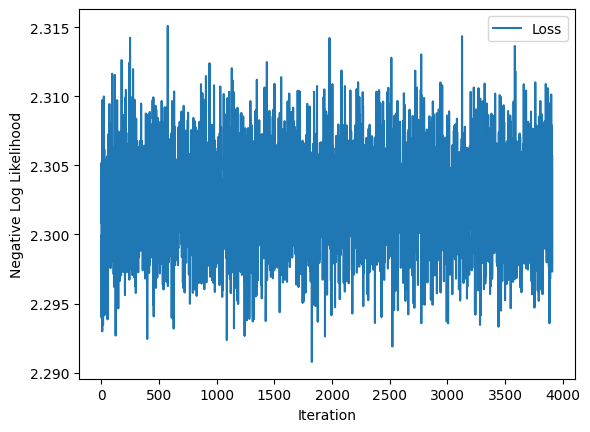


Starte Training: CNN mit Augmentation (10 Epochen)…
* CNN mit Augmentation: Test-Accuracy nach 10 Epochen = 10.01 %


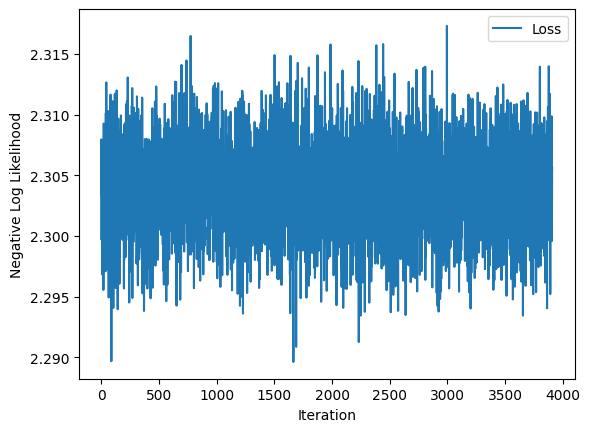

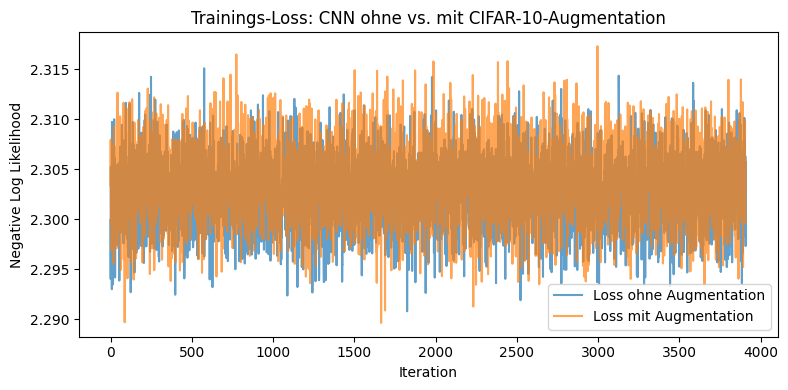


–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
Finale Test-Accuracy des CNN ohne Augmentation: 9.88 %
Finale Test-Accuracy des CNN mit Augmentation:  10.01 %


In [13]:
# Bonus: Vergleichen Sie die Trainingergebnisse eines CNN, das trainiert wurde 
#mit und ohne augmentierten Bildern.

# ----------------------------------------
# Datenvorbereitung mit lokalem Pfad ("./data")
# ----------------------------------------
batch_size = 128

# Ohne Augmentation: nur ToTensor()
transform_no_aug = T.Compose([
    T.ToTensor()
])

# Mit Augmentation: RandomCrop + Flip + ColorJitter + ToTensor()
transform_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor()
])

# CIFAR-10 Trainingssets (jeweils in "./data")
train_set_no_aug = torchvision.datasets.CIFAR10(
    root="./data",  # <> statt "/mnt/data"
    train=True,
    download=True,
    transform=transform_no_aug
)
train_set_aug = torchvision.datasets.CIFAR10(
    root="./data",  # dieselbe "./data"-Struktur
    train=True,
    download=False,
    transform=transform_aug
)

# CIFAR-10 Testset (ohne Augmentation)
test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_no_aug
)

# DataLoader
train_loader_no_aug = torch.utils.data.DataLoader(
    train_set_no_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)
train_loader_aug = torch.utils.data.DataLoader(
    train_set_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# ----------------------------------------
# CNN ohne Augmentation trainieren
# ----------------------------------------
cnn_no_aug = SimpleClassifierCNN()
optim_no_aug = torch.optim.Adam(cnn_no_aug.parameters(), lr=0.001)

print("Starte Training: CNN ohne Augmentation (10 Epochen)…")
loss_no_aug = train_multiclass(10, cnn_no_aug, optim_no_aug, train_loader_no_aug)
#acc_no_aug = eval_multiclass(cnn_no_aug, test_loader)
#print(f"* CNN ohne Augmentation: Test-Accuracy nach 10 Epochen = {acc_no_aug:.2f} %")
acc_no_aug, _  = eval_multiclass(cnn_no_aug, test_loader)
print(f"* CNN ohne Augmentation: Test-Accuracy nach 10 Epochen = {acc_no_aug:.2f} %")
show_loss_curve(loss_no_aug)

# ----------------------------------------
# CNN mit Augmentation trainieren
# ----------------------------------------
cnn_aug = SimpleClassifierCNN()
optim_aug = torch.optim.Adam(cnn_aug.parameters(), lr=0.001)

print("\nStarte Training: CNN mit Augmentation (10 Epochen)…")
loss_aug = train_multiclass(10, cnn_aug, optim_aug, train_loader_aug)
#acc_aug = eval_multiclass(cnn_aug, test_loader)
#print(f"* CNN mit Augmentation: Test-Accuracy nach 10 Epochen = {acc_aug:.2f} %")
acc_aug, _ = eval_multiclass(cnn_aug, test_loader)
print(f"* CNN mit Augmentation: Test-Accuracy nach 10 Epochen = {acc_aug:.2f} %")
show_loss_curve(loss_aug)

# ----------------------------------------
# Vergleich der Loss-Kurven beider Modelle
# ----------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(loss_no_aug, label="Loss ohne Augmentation", alpha=0.7)
plt.plot(loss_aug, label="Loss mit Augmentation", alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("Trainings-Loss: CNN ohne vs. mit CIFAR-10-Augmentation")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------
# Endergebnis ausgeben
# ----------------------------------------
print("\n–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––")
print(f"Finale Test-Accuracy des CNN ohne Augmentation: {acc_no_aug:.2f} %")
print(f"Finale Test-Accuracy des CNN mit Augmentation:  {acc_aug:.2f} %")

